# Imports & Config

In [5]:
#!pip install matplotlib

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
#import matplotlib.pyplt as plt
import matplotlib.pyplot as plt


# Loading Feature-Engineered Data

In [7]:
data = pd.read_csv("processed/final_customer_features.csv")
data.head()

,customer_unique_id,Recency,Frequency,Monetary,avg_delivery_time,avg_items,avg_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,6.0,1.0,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3.0,1.0,1.0
2,0000f46a3911fa3c0805444483337064,537,1,86.22,25.0,1.0,8.0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,20.0,1.0,4.0
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,13.0,1.0,6.0


In [8]:
#Basic Validation
assert data[['Recency', 'Frequency', 'Monetary']].isnull().sum().sum() == 0
assert (data[['Recency', 'Frequency', 'Monetary']] < 0).sum().sum() == 0

# RFM Scaling 

In [9]:
rfm = data[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Optimal K Selection

### Elbow Method

In [10]:
wcss = []
K_range = range(2, 11)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    wcss.append(model.inertia_)

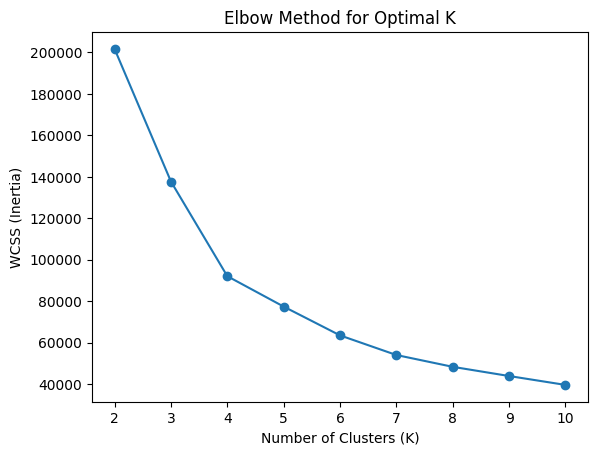

In [11]:
plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

### Silhouette Score

In [12]:
silhouette_scores = {}
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(rfm_scaled)
    silhouette_scores[k] = silhouette_score(rfm_scaled, labels)
silhouette_scores

{2: 0.7389413038668743,
 3: 0.4559658029676103,
 4: 0.48860849278699137,
 5: 0.41870450946470084,
 6: 0.4369710566922809,
 7: 0.43943528759888867,
 8: 0.4485195568414554,
 9: 0.3897894136469181,
 10: 0.38272255553518475}

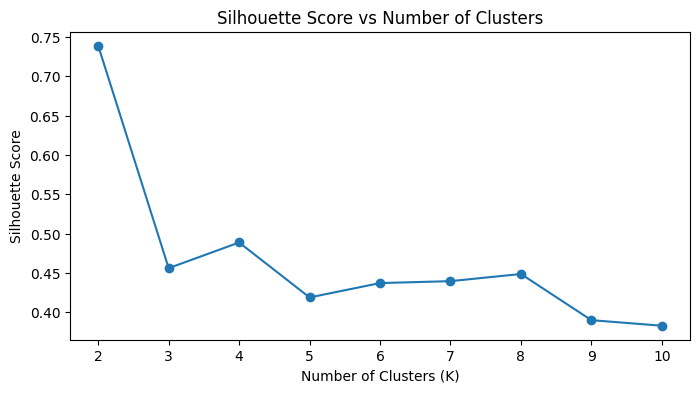

In [16]:
plt.figure(figsize=(8,4))
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o'
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

In [17]:
OPTIMAL_K=4  #choosed optimal k value

# Train Final KMeans Model

In [18]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20
)
data['cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster Profiling

In [19]:
cluster_profile = (
    data
    .groupby('cluster')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(2)
)
cluster_profile

,Recency,Frequency,Monetary
cluster,,,
0,387.41,1.00,133.46
1,220.44,2.11,289.68
2,239.40,1.01,1160.91
3,128.07,1.00,134.36


# Cluster Ranking

In [20]:
cluster_profile['R_rank'] = cluster_profile['Recency'].rank(ascending=True)
cluster_profile['F_rank'] = cluster_profile['Frequency'].rank(ascending=False)
cluster_profile['M_rank'] = cluster_profile['Monetary'].rank(ascending=False)
cluster_profile['RFM_Score'] = (
    cluster_profile['R_rank'] +
    cluster_profile['F_rank'] +
    cluster_profile['M_rank']
)
cluster_profile = cluster_profile.sort_values('RFM_Score')
cluster_profile

,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,RFM_Score
cluster,,,,,,,
1,220.44,2.11,289.68,2.0,1.0,2.0,5.0
2,239.40,1.01,1160.91,3.0,2.0,1.0,6.0
3,128.07,1.00,134.36,1.0,3.5,3.0,7.5
0,387.41,1.00,133.46,4.0,3.5,4.0,11.5


# Map Cluster → RFM Segment Level

In [21]:
cluster_profile['segment_level'] = [
    "High Value",
    "Medium Value",
    "Low Value",
    "At Risk"
][:len(cluster_profile)]
cluster_profile

,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,RFM_Score,segment_level
cluster,,,,,,,,
1,220.44,2.11,289.68,2.0,1.0,2.0,5.0,High Value
2,239.40,1.01,1160.91,3.0,2.0,1.0,6.0,Medium Value
3,128.07,1.00,134.36,1.0,3.5,3.0,7.5,Low Value
0,387.41,1.00,133.46,4.0,3.5,4.0,11.5,At Risk


# Save Model

In [24]:
print(type(kmeans))
print(type(scaler))
print(type(cluster_profile))

<class 'sklearn.cluster._kmeans.KMeans'>
<class 'sklearn.preprocessing._data.StandardScaler'>
<class 'pandas.core.frame.DataFrame'>


In [25]:
os.makedirs("models", exist_ok=True)
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/rfm_scaler.pkl")
cluster_profile.to_csv("models/cluster_profile.csv",index=False)
print("✅ Models saved successfully")

✅ Models saved successfully


In [26]:
print(os.getcwd())

C:\Users\urvas\Downloads\Customer segmentation\notebooks


# Save Customer-Level Output

In [27]:
data.to_csv("processed/customer_rfm_clustered.csv", index=False)

In [28]:
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/rfm_scaler.pkl")
print("✅ Models saved successfully")

✅ Models saved successfully
